# EDA: Retrosheet steal-attempt data (2021-2025)

Sanity-checks the output of `src/retrosheet_parser.py` before we build
anything on top of it. The goal here is purely **"is the data good?"** —
no modeling, no decision layer. Starts with a deep dive on 2023 (the
season shipped with the repo), then extends the same checks to 2021,
2022, 2024, and 2025.

We already know a few facts from public sources, so we can check the
parsed data against them:

- Ronald Acuña Jr. led MLB in stolen bases in 2023 with **73**.
- Elly De La Cruz led MLB in stolen bases in 2024 with **67**.
- League-wide stolen-base success rate jumped from ~75% (2021-2022) to
  ~78-80% (2023-2025) because of the 2023 pickoff-limit / bigger-base
  rules. Because that rule change shifted the underlying success-rate
  distribution, **2021 and 2022 are kept here for comparison but excluded
  from the feature table / model training** — see section 10.
- Every steal attempt should resolve to a real runner on base.


In [1]:
import pandas as pd

steals = pd.read_csv("../data/sample/steals_2023.csv")
print(steals.shape)
steals.head()


(4439, 22)


,game_id,date,park,inning,half,outs,target_base,runner_id,runner_bats,pitcher_id,...,batter_id,count,score_bat,score_def,score_diff,on_1b,on_2b,on_3b,success,double_steal
0,HOU202310160,2023/10/16,HOU03,3,0,2,2,tavel001,B,montr004,...,semim001,10,5,1,4,tavel001,NaN,NaN,1,0
1,TEX202310190,2023/10/19,ARL03,7,0,0,2,abrej003,R,smitw002,...,tuckk001,12,7,3,4,abrej003,NaN,NaN,1,0
2,TEX202310200,2023/10/20,ARL03,8,1,2,2,tavel001,B,presr001,...,lowen001,1,4,2,2,tavel001,NaN,carte001,1,0
3,HOU202310220,2023/10/22,HOU03,1,1,0,2,altuj001,R,eovan001,...,branm003,22,0,0,0,altuj001,NaN,NaN,1,0
4,HOU202310220,2023/10/22,HOU03,8,0,0,2,carte001,L,abreb002,...,garca005,10,3,2,1,carte001,NaN,NaN,1,0


## 1. Shape, dtypes, date range — does this look like a full season?

In [2]:
print(f"rows: {len(steals)}")
print(f"date range: {steals['date'].min()} to {steals['date'].max()}")
print(f"unique games: {steals['game_id'].nunique()}")
print(f"unique runners: {steals['runner_id'].nunique()}")
steals.dtypes


rows: 4439
date range: 2023/03/30 to 2023/11/01
unique games: 1938
unique runners: 493


game_id           object
date              object
park              object
inning             int64
half               int64
outs               int64
target_base       object
runner_id         object
runner_bats       object
pitcher_id        object
pitcher_throws    object
catcher_id        object
batter_id         object
count              int64
score_bat          int64
score_def          int64
score_diff         int64
on_1b             object
on_2b             object
on_3b             object
success            int64
double_steal       int64
dtype: object

## 2. Every attempt resolves to a runner?

If the parser lost track of base occupancy, `runner_id` would be null for
some steal attempts. It shouldn't be.


In [3]:
missing_runner = steals["runner_id"].isna().sum()
print(f"attempts with no resolved runner: {missing_runner} / {len(steals)}")
assert missing_runner == 0


attempts with no resolved runner: 0 / 4439


## 3. League-wide success rate — should be close to 80% for 2023.

In [4]:
success_rate = steals["success"].mean()
print(f"league SB success rate: {success_rate:.1%}")
sb = steals["success"].sum()
cs = len(steals) - sb
print(f"SB: {sb}   CS: {cs}   total attempts: {len(steals)}")


league SB success rate: 80.2%
SB: 3561   CS: 878   total attempts: 4439


## 4. Stolen bases per player, 2023 — leaderboard cross-check

This is the most direct sanity check: sum up successful steals per
`runner_id` and see if the top of the list matches what actually happened
in 2023. Acuña should be #1 with 73.


In [5]:
sb_by_player = (
    steals[steals["success"] == 1]
    .groupby("runner_id")
    .size()
    .sort_values(ascending=False)
)
sb_by_player.head(15)


runner_id
acunr001    75
ruize001    65
carrc005    59
wittb002    49
abrac001    47
hoern001    43
kim-h002    38
rodrj007    37
stotb001    36
delae003    34
turnt001    34
lowej002    32
lindf001    31
castw003    31
tuckk001    30
dtype: int64

In [6]:
acuna = sb_by_player.get("acunr001")
print(f"Acuna Jr. (acunr001) stolen bases: {acuna}")
assert sb_by_player.index[0] == "acunr001"
assert acuna >= 70


Acuna Jr. (acunr001) stolen bases: 75


## 5. Attempts per player too (success rate isn't the whole picture)

A player can have a great SB total but a mediocre success rate if they run
a lot. Combine both.


In [7]:
attempts_by_player = steals.groupby("runner_id").size()
success_by_player = steals.groupby("runner_id")["success"].mean()

leaderboard = pd.DataFrame({
    "sb": sb_by_player,
    "attempts": attempts_by_player,
}).fillna(0)
leaderboard["cs"] = leaderboard["attempts"] - leaderboard["sb"]
leaderboard["success_rate"] = leaderboard["sb"] / leaderboard["attempts"]
leaderboard.sort_values("sb", ascending=False).head(15)


,sb,attempts,cs,success_rate
runner_id,,,,
acunr001,75.0,89,14.0,0.842697
ruize001,65.0,78,13.0,0.833333
carrc005,59.0,65,6.0,0.907692
wittb002,49.0,64,15.0,0.765625
abrac001,47.0,51,4.0,0.921569
hoern001,43.0,50,7.0,0.860000
kim-h002,38.0,47,9.0,0.808511
rodrj007,37.0,47,10.0,0.787234
stotb001,36.0,39,3.0,0.923077


## 6. Target base breakdown

Stealing second should be by far the most common attempt; third much
rarer; home very rare. Success rate should drop as the target base gets
harder (2nd easiest, home hardest).


In [8]:
base_summary = steals.groupby("target_base").agg(
    attempts=("success", "size"),
    success_rate=("success", "mean"),
).sort_values("attempts", ascending=False)
base_summary


,attempts,success_rate
target_base,,
2,3780,0.800000
3,610,0.840984
H,49,0.489796


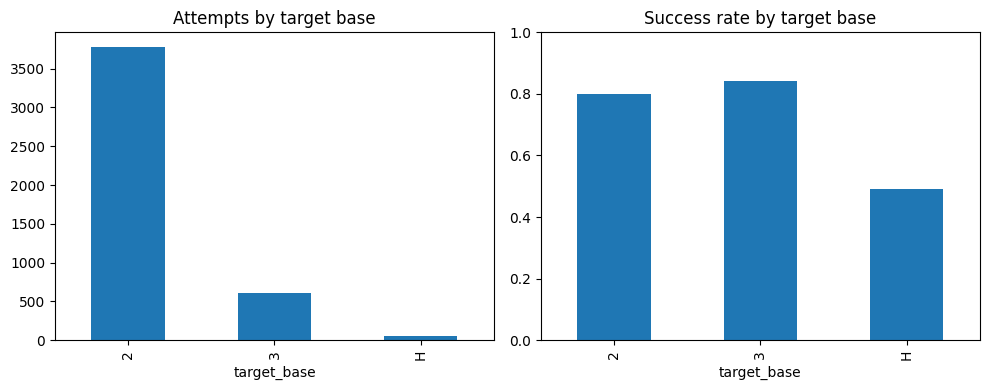

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
base_summary["attempts"].plot(kind="bar", ax=axes[0], title="Attempts by target base")
base_summary["success_rate"].plot(kind="bar", ax=axes[1], title="Success rate by target base", ylim=(0, 1))
plt.tight_layout()
plt.show()


## 7. Situational distribution — outs, inning, score — anything look broken?

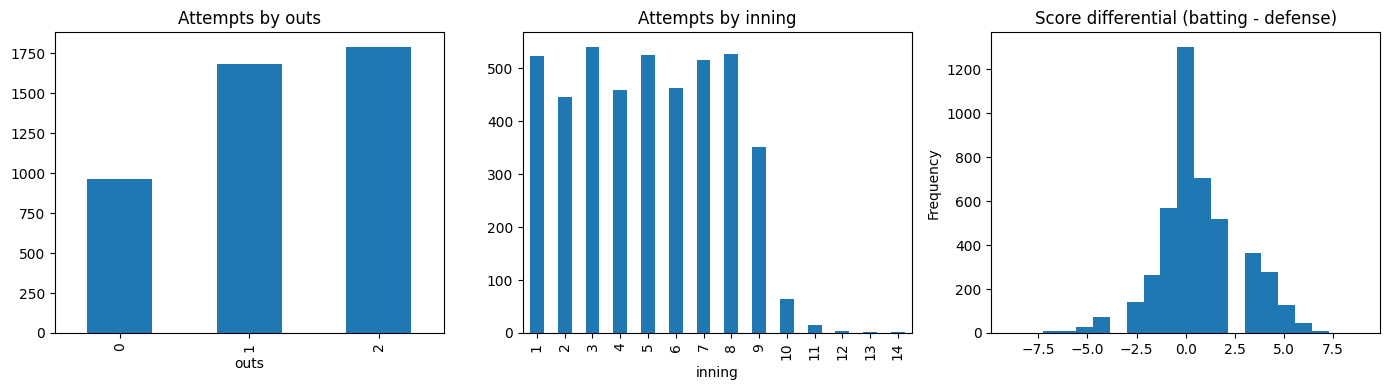

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
steals["outs"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Attempts by outs")
steals["inning"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Attempts by inning")
steals["score_diff"].plot(kind="hist", bins=21, ax=axes[2], title="Score differential (batting - defense)")
plt.tight_layout()
plt.show()


## 8. Multi-steal same-play snapshots (known, documented quirk)

The brief notes ~0.6% of attempts sit in same-play multi-steal snapshots
(e.g. a double steal where two runners go on the same pitch). Confirm the
rate is still in that ballpark and not something new.


In [11]:
dupe_plays = steals.groupby(["game_id", "inning", "half", "outs"]).size()
multi = (dupe_plays > 1).sum()
print(f"base-out states with >1 attempt logged: {multi} ({multi / len(dupe_plays):.2%} of state-groups)")


base-out states with >1 attempt logged: 329 (8.05% of state-groups)


## 9. Statcast join validation

We now have `data/statcast/id_crosswalk.csv` (Retrosheet id <-> MLBAM id,
built from the Chadwick Bureau register) plus Statcast's 2023 sprint-speed
and catcher pop-time leaderboards. Before trusting any joined feature, check
that the join actually lands on real players with sensible values — the
fastest runners among our steal attempts should be recognizable burners
(Elly De La Cruz, Bobby Witt Jr., etc.), not noise.


In [12]:
crosswalk = pd.read_csv("../data/statcast/id_crosswalk.csv")
sprint = pd.read_csv("../data/statcast/sprint_speed_2023.csv")
poptime = pd.read_csv("../data/statcast/catcher_poptime_2023.csv")

joined = steals.merge(crosswalk, left_on="runner_id", right_on="key_retro", how="left")
joined = joined.merge(sprint[["player_id", "sprint_speed"]],
                      left_on="key_mlbam", right_on="player_id", how="left")

print(f"steal attempts: {len(joined)}")
print(f"runner_id not found in crosswalk: {joined['key_mlbam'].isna().sum()}")
print(f"crosswalked but no sprint-speed row: "
      f"{joined['key_mlbam'].notna().sum() - joined['sprint_speed'].notna().sum()}")


steal attempts: 4439
runner_id not found in crosswalk: 0
crosswalked but no sprint-speed row: 4


In [13]:
fastest = (
    joined[["runner_id", "sprint_speed"]]
    .drop_duplicates("runner_id")
    .sort_values("sprint_speed", ascending=False)
    .head(10)
)
fastest


,runner_id,sprint_speed
100,delae003,30.5
148,wittb002,30.5
198,turnt001,30.3
865,bland001,30.3
1070,thomb003,30.2
135,carrc005,30.1
113,matej003,30.1
3714,fitzt001,30.1
1033,lawlj001,30.0
1165,perkb002,30.0


In [14]:
# De La Cruz and Witt Jr. were the two fastest players in MLB by sprint
# speed in 2023 -- if the join is correct they should be at (or very near)
# the top of this list.
top_runner_ids = set(fastest["runner_id"].head(3))
assert "delae003" in top_runner_ids or "wittb002" in top_runner_ids, \
    "expected an elite burner (De La Cruz / Witt Jr.) atop the sprint-speed join"
print("join sanity check passed: known burners are on top")


join sanity check passed: known burners are on top


Same check for catcher pop time — lower pop time is better (faster to second).

In [15]:
joined_catcher = steals.merge(crosswalk, left_on="catcher_id", right_on="key_retro", how="left")
joined_catcher = joined_catcher.merge(
    poptime[["entity_id", "pop_2b_sba"]],
    left_on="key_mlbam", right_on="entity_id", how="left",
)
print(f"catcher_id not found in crosswalk: {joined_catcher['key_mlbam'].isna().sum()}")
print(f"crosswalked but no pop-time row: "
      f"{joined_catcher['key_mlbam'].notna().sum() - joined_catcher['pop_2b_sba'].notna().sum()}")
joined_catcher[["catcher_id", "pop_2b_sba"]].drop_duplicates("catcher_id").sort_values("pop_2b_sba").head(10)


catcher_id not found in crosswalk: 0
crosswalked but no pop-time row: 1


,catcher_id,pop_2b_sba
204,realj001,1.83
210,bethc001,1.87
205,stubg001,1.87
12,pintr003,1.87
95,bailp001,1.87
318,tromc001,1.88
189,murps001,1.90
248,sancg002,1.90
142,moreg001,1.90
44,diazy004,1.90


## 10. Multi-season consistency — 2021, 2022, 2024, 2025

We now have parsed steal-attempt tables for 2021, 2022, 2023, 2024, and
2025 (`data/sample/steals_<year>.csv`), pulled via `src/fetch_retrosheet.py`.
Before treating these as usable data, check them the same way we checked
2023: unresolved runners, plausible success rates, and a leaderboard
cross-check against known facts.

One extra thing to look for here: MLB's 2023 rule changes (bigger bases,
limited pickoff attempts) were specifically meant to boost stolen-base
success — so success rate should visibly step up starting in 2023 and hold
in 2024-2025, versus 2021/2022. That step-up is *why* `src/features.py`
excludes 2021-2022 by default: they aren't drawn from the same
success-rate distribution the model needs to predict.


In [16]:
import glob

season_files = sorted(glob.glob("../data/sample/steals_*.csv"))
seasons = {}
for f in season_files:
    year = f.split("_")[-1].replace(".csv", "")
    seasons[year] = pd.read_csv(f)

summary_rows = []
for year, df in sorted(seasons.items()):
    summary_rows.append({
        "season": year,
        "attempts": len(df),
        "unresolved_runner": df["runner_id"].isna().sum(),
        "success_rate": df["success"].mean(),
    })
season_summary = pd.DataFrame(summary_rows).set_index("season")
season_summary


,attempts,unresolved_runner,success_rate
season,,,
2021,2972,4,0.759421
2022,3341,0,0.754265
2023,4439,0,0.802208
2024,4651,0,0.791013
2025,4478,0,0.776463


In [17]:
# Sanity bounds per season, and the 2023 rule-change step-up in particular.
for year, row in season_summary.iterrows():
    assert row["unresolved_runner"] / row["attempts"] < 0.005, \
        f"{year}: too many unresolved runners"
    assert 0.70 <= row["success_rate"] <= 0.85, \
        f"{year}: success rate {row['success_rate']:.1%} out of plausible range"

pre_rule_change = season_summary.loc[["2021", "2022"], "success_rate"].mean()
post_rule_change = season_summary.loc[["2023", "2024", "2025"], "success_rate"].mean()
print(f"avg success rate 2021-2022 (pre rule change): {pre_rule_change:.1%}")
print(f"avg success rate 2023-2025 (post rule change): {post_rule_change:.1%}")
assert post_rule_change > pre_rule_change + 0.02, \
    "expected a visible bump in success rate after the 2023 rule changes"
print("rule-change bump confirmed in the data -- this is why features.py "
      "excludes 2021-2022 by default")


avg success rate 2021-2022 (pre rule change): 75.7%
avg success rate 2023-2025 (post rule change): 79.0%
rule-change bump confirmed in the data -- this is why features.py excludes 2021-2022 by default


### Leaderboard cross-check for a second season (2024)

Elly De La Cruz led MLB in stolen bases in 2024 with 67; Shohei Ohtani was
second with 59 (part of his 50/50 season). If the parser generalizes
correctly beyond 2023, these should show up here too.


In [18]:
sb_2024 = (
    seasons["2024"][seasons["2024"]["success"] == 1]
    .groupby("runner_id")
    .size()
    .sort_values(ascending=False)
)
print(sb_2024.head(5))
assert sb_2024.index[0] == "delae003" and sb_2024.iloc[0] >= 60
print("2024 leaderboard cross-check passed")


runner_id
delae003    67
ohtas001    59
turab002    52
chisj001    46
ramij003    43
dtype: int64
2024 leaderboard cross-check passed


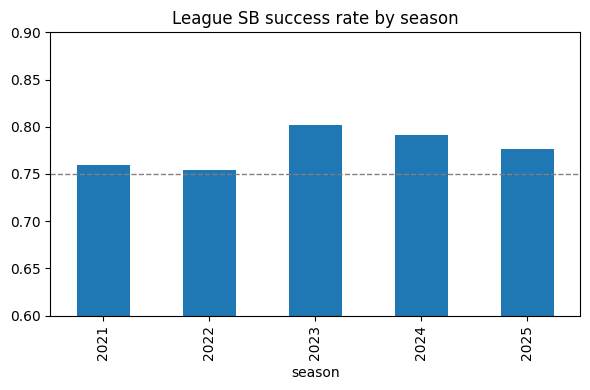

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
season_summary["success_rate"].plot(kind="bar", ax=ax, ylim=(0.6, 0.9),
                                    title="League SB success rate by season")
ax.axhline(0.75, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


## 10.5 Double steals — correcting an earlier claim

Early project notes claimed "~0.6% of attempts are same-play multi-steal
snapshots (documented, benign)." That number turns out to be wrong.
Retrosheet encodes a genuine simultaneous double steal (two runners
breaking on the SAME pitch) as multiple `SB`/`CS` tokens on one play line,
e.g. `SB3;SB2` -- that's the reliable signal, not just "same out count"
(which also catches unrelated, sequential steals later in the same
half-inning that happen to share an out count).


In [20]:
import re

def is_true_double_steal(event):
    tokens = re.findall(r"(?:SB|CS|POCS)[23H]", event.split(".")[0])
    return len(tokens) > 1

double_steal_plays = 0
double_steal_rows = 0
double_steal_all_safe = True
total_plays = 0
for f in sorted(glob.glob("../data/retrosheet_202[345]/*.EV*")):
    with open(f, newline="") as fh:
        for line in fh:
            if not line.startswith("play,"):
                continue
            event = line.strip().split(",", 6)[-1]
            if re.search(r"(SB|CS|POCS)[23H]", event):
                total_plays += 1
                if is_true_double_steal(event):
                    double_steal_plays += 1
                    tokens = re.findall(r"(?:SB|CS|POCS)[23H]", event.split(".")[0])
                    double_steal_rows += len(tokens)
                    if any(not t.startswith("SB") for t in tokens):
                        double_steal_all_safe = False

print(f"steal plays (2023-2025): {total_plays}")
print(f"true simultaneous double-steal plays: {double_steal_plays} "
      f"({double_steal_plays/total_plays:.1%} of plays)")
print(f"attempt-rows from double steals: {double_steal_rows} "
      f"({double_steal_rows/(total_plays + double_steal_rows - double_steal_plays):.1%} of rows, "
      f"roughly)")
print(f"every double-steal play resulted in all runners safe: {double_steal_all_safe}")

steal plays (2023-2025): 13087
true simultaneous double-steal plays: 481 (3.7% of plays)
attempt-rows from double steals: 962 (7.1% of rows, roughly)
every double-steal play resulted in all runners safe: True


So the real rate is roughly **3.7% of steal plays / 7.1% of attempt-rows**,
not 0.6% -- and every single one of those plays, across three full
seasons, ended with every runner safe. A catcher facing two runners
breaking together essentially never throws either one out in this data
(the defense can only really contest one runner). That's a strong,
almost deterministic signal that was previously invisible to the model --
`src/retrosheet_parser.py` now tags it directly (`double_steal` column,
set when a play's `find_steal_events` returns more than one token), and
`src/features.py` exposes it as `is_double_steal`.


## 11. Feature table validation

`src/features.py` combines the post-rule-change seasons (2023-2025, the
default `--seasons`) into one chronologically ordered, leakage-safe
feature table (`data/sample/features_2023_2025.csv`): running
runner/pitcher/catcher priors computed only from *prior* attempts (carried
across season boundaries), plus a season-matched Statcast join (runner
sprint speed, catcher pop time) via the id crosswalk. 2021-2022 are
deliberately left out (see section 10). Check that the leakage-safety and
join actually hold before this becomes training data.


In [21]:
features = pd.read_csv("../data/sample/features_2023_2025.csv")
print(f"rows: {len(features)}   seasons: {sorted(features['season'].unique())}")
features.head()


rows: 13568   seasons: [np.int64(2023), np.int64(2024), np.int64(2025)]


,season,date,runner_id,pitcher_id,catcher_id,target_base,steal_of_third,steal_of_home,inning,late_inning,...,runner_prior_att,pitcher_prior_sr_allowed,catcher_prior_cs_rate,runner_sprint_speed,runner_sprint_speed_missing,runner_age,runner_age_missing,catcher_pop_time,catcher_pop_time_missing,success
0,2023,2023/03/30,matej003,klubc001,mcgur002,2,0,0,4,0,...,0,0.7500,0.2000,30.1,0,28.0,0,1.98,0,1
1,2023,2023/03/30,fraza001,brasr001,mcgur002,2,0,0,5,0,...,0,0.7500,0.1667,26.5,0,31.0,0,1.98,0,1
2,2023,2023/03/30,matej003,brasr001,mcgur002,2,0,0,5,0,...,1,0.7917,0.1429,30.1,0,28.0,0,1.98,0,1
3,2023,2023/03/30,mullc002,brasr001,mcgur002,2,0,0,5,0,...,0,0.8214,0.1250,28.0,0,28.0,0,1.98,0,1
4,2023,2023/03/30,mullc002,ort-k001,mcgur002,2,0,0,7,1,...,1,0.7500,0.1111,28.0,0,28.0,0,1.98,0,1


In [22]:
# features.py already writes rows in chronological order (date, game_id,
# inning, outs), so we check leakage using that file order directly rather
# than re-sorting in pandas (its default sort isn't stable, and many
# attempts share the same date -- re-sorting can silently reshuffle
# same-day order and produce false positives here).

# A handful of rows have no resolved runner_id -- the same documented,
# benign parser edge case flagged in section 2 (4 cases, all 2021). Exclude
# them from the per-runner leakage check since they aren't a real runner.
resolved = features[features["runner_id"].notna()]

first_attempts = resolved.groupby("runner_id", sort=False).head(1)
bad_first = (first_attempts["runner_prior_att"] != 0).sum()
print(f"first attempts with nonzero prior_att: {bad_first}")
assert bad_first == 0, "leakage: a runner's first attempt has prior history"

running_count = resolved.groupby("runner_id", sort=False).cumcount()
mismatch = (resolved["runner_prior_att"] != running_count).sum()
print(f"prior_att / running-count mismatches: {mismatch}")
assert mismatch == 0
print("leakage checks passed")


first attempts with nonzero prior_att: 0
prior_att / running-count mismatches: 0
leakage checks passed


In [23]:
# Statcast join coverage should be near-complete (we saw <30 misses per
# season in the raw join checks above).
missing_sprint = features["runner_sprint_speed_missing"].mean()
missing_pop = features["catcher_pop_time_missing"].mean()
print(f"missing runner sprint speed: {missing_sprint:.2%}")
print(f"missing catcher pop time: {missing_pop:.2%}")
assert missing_sprint < 0.01 and missing_pop < 0.01

# Sprint speed should differ meaningfully by season (skills fluctuate
# year to year) but stay in a plausible MLB range (roughly 23-31 ft/s).
speed_by_season = features.groupby("season")["runner_sprint_speed"].mean()
print(speed_by_season)
assert features["runner_sprint_speed"].between(20, 32).mean() > 0.99


missing runner sprint speed: 0.13%
missing catcher pop time: 0.07%
season
2023    28.170349
2024    28.089604
2025    28.001253
Name: runner_sprint_speed, dtype: float64


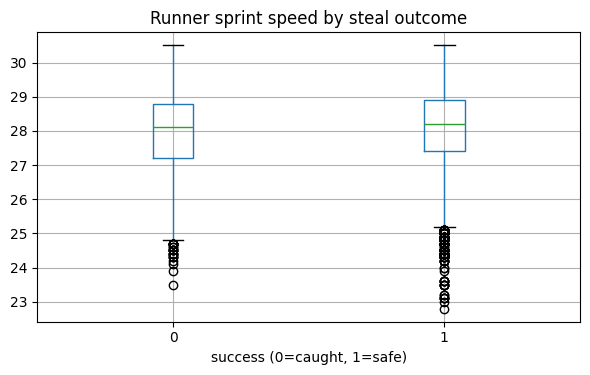

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
features.boxplot(column="runner_sprint_speed", by="success", ax=ax)
ax.set_title("Runner sprint speed by steal outcome")
ax.set_xlabel("success (0=caught, 1=safe)")
plt.suptitle("")
plt.tight_layout()
plt.show()


### Pitcher handedness

Added after the fact: `pitcher_throws_lhp` (from the same roster files
used for `runner_bats`). Lefties are known to hold runners at first much
better than righties, so success rate against them should be visibly
lower.


In [25]:
throws_summary = features.groupby("pitcher_throws_lhp")["success"].agg(["size", "mean"])
throws_summary.index = ["RHP", "LHP"]
print(throws_summary)
assert throws_summary.loc["LHP", "mean"] < throws_summary.loc["RHP", "mean"], \
    "expected a lower steal success rate against lefties"
print("handedness effect confirmed in the data")


      size      mean
RHP  10056  0.796539
LHP   3512  0.770786
handedness effect confirmed in the data


Faster runners should succeed more often -- if the boxplot above shows
`success=1` skewed toward higher sprint speed than `success=0`, the join
is not just present but *predictive*, which is the whole point of adding
it.


## 12. Model diagnostics

`src/train.py` trains a logistic regression baseline and an XGBoost model
on `features_2023_2025.csv` with a date-based train/test split (see the
module docstring for why -- no future-into-past leakage). With
`is_double_steal`, `steal_of_third`/`steal_of_home`, and `runner_age`
added (see section 10.5), both models now land around **AUC 0.65** --
up from ~0.60 with the earlier feature set. This section shows why the
earlier version was weak and what closed part of the gap, reusing the
exact same training code (`src.train`) so these numbers always match what
`python -m src.train --diagnostics` prints on the command line.


In [26]:
import sys
sys.path.insert(0, "..")
from src.train import NUMERIC, fit_logistic, fit_xgboost, confusion_at

model_df = pd.read_csv("../data/sample/features_2023_2025.csv")
for col in ("runner_sprint_speed", "catcher_pop_time"):
    model_df[col] = model_df[col].fillna(model_df[col].median())

split_idx = int(len(model_df) * 0.8)
mtrain, mtest = model_df.iloc[:split_idx], model_df.iloc[split_idx:]
X_tr, y_tr = mtrain[NUMERIC].fillna(0.0), mtrain["success"].astype(int)
X_te, y_te = mtest[NUMERIC].fillna(0.0), mtest["success"].astype(int)

print(f"train: {mtrain['date'].min()} to {mtrain['date'].max()} ({len(mtrain)} rows)")
print(f"test : {mtest['date'].min()} to {mtest['date'].max()} ({len(mtest)} rows)")
print(f"test base rate: {y_te.mean():.3f}")

log_model = fit_logistic(X_tr, y_tr)
xgb_model = fit_xgboost(X_tr, y_tr)
p_log = log_model.predict_proba(X_te)[:, 1]
p_xgb = xgb_model.predict_proba(X_te)[:, 1]


train: 2023/03/30 to 2025/06/01 (10854 rows)
test : 2025/06/01 to 2025/11/01 (2714 rows)
test base rate: 0.777


  (early stopping: best iteration 155 of 300)


### Confusion matrix at two thresholds

A standard 0.5 cutoff is meaningless here: steal success is a ~78%
base-rate event, so if the model predicts P(success) > 0.5 for
(virtually) every attempt, it never once predicts "caught" -- that's a
statement about the base rate, not the model. The base-rate threshold
(~0.78) is a more honest look at how well the model separates the two
classes.


In [27]:
base_rate = y_te.mean()
rows = []
for name, p in [("Logistic regression", p_log), ("XGBoost", p_xgb)]:
    for label, thresh in [("0.5", 0.5), (f"base rate ({base_rate:.3f})", base_rate)]:
        c = confusion_at(y_te, p, thresh)
        rows.append({"model": name, "threshold": label, **c})
pd.DataFrame(rows).set_index(["model", "threshold"])


tp   fp   tn   fn  precision  \
model               threshold                                           
Logistic regression 0.5                2108  589   16    1   0.781609   
                    base rate (0.777)  1246  228  377  863   0.845319   
XGBoost             0.5                2107  584   21    2   0.782980   
                    base rate (0.777)  1272  257  348  837   0.831916   

                                         recall  specificity  
model               threshold                                 
Logistic regression 0.5                0.999526     0.026446  
                    base rate (0.777)  0.590801     0.623140  
XGBoost             0.5                0.999052     0.034711  
                    base rate (0.777)  0.603129     0.575207

### Same thing, visually

Rows = model, columns = threshold. Bottom-left of each 2x2 grid (true
"caught", predicted "safe") and top-right (true "safe", predicted
"caught") are the two error types; the diagonal is correct predictions.
At threshold 0.5, the entire "caught" row predicts "safe" -- zero correct
"caught" predictions for logistic regression, 3 for XGBoost.


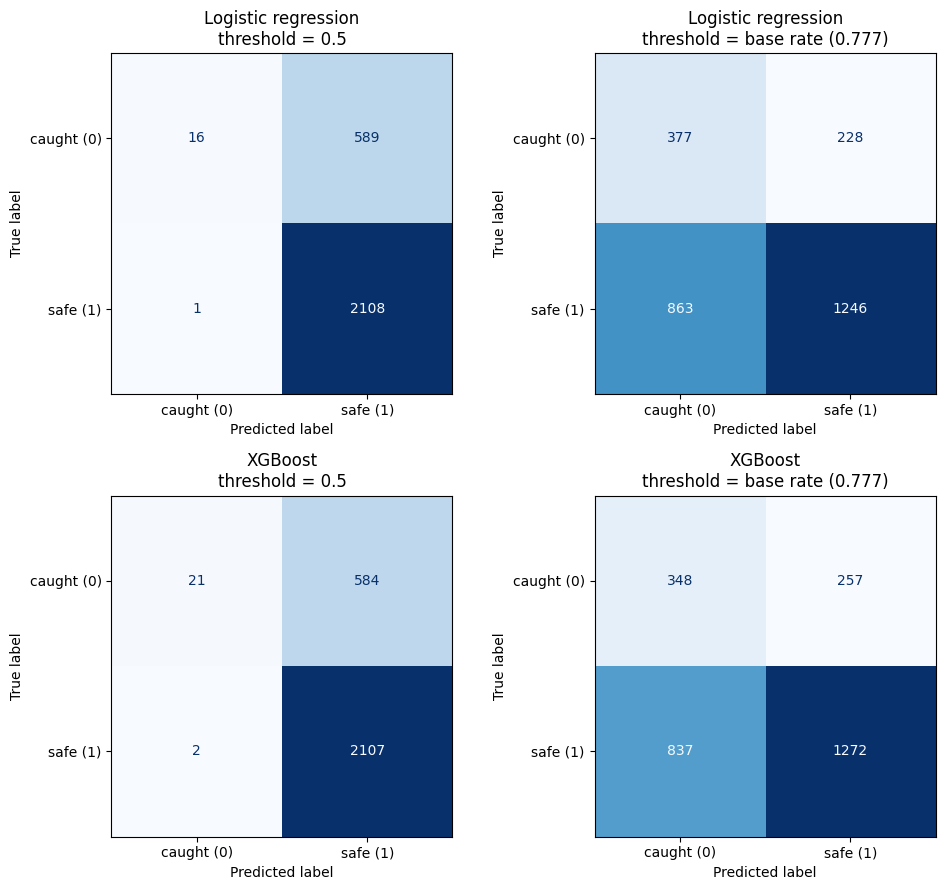

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row, (name, p) in enumerate([("Logistic regression", p_log), ("XGBoost", p_xgb)]):
    for col, (label, thresh) in enumerate([("threshold = 0.5", 0.5),
                                           (f"threshold = base rate ({base_rate:.3f})", base_rate)]):
        pred = (p >= thresh).astype(int)
        cm = confusion_matrix(y_te, pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(cm, display_labels=["caught (0)", "safe (1)"])
        disp.plot(ax=axes[row][col], colorbar=False, cmap="Blues")
        axes[row][col].set_title(f"{name}\n{label}")
plt.tight_layout()
plt.show()


### Most confident wrong predictions

Where the model is most confidently wrong tells us more than the
aggregate metrics. If the misses were random noise, they'd have
unremarkable stats in both directions. Instead:


In [29]:
scored = mtest.copy()
scored["p_log"] = p_log
scored["p_xgb"] = p_xgb
id_cols = ["runner_id", "pitcher_id", "catcher_id"]
skill_cols = ["runner_sprint_speed", "catcher_pop_time", "runner_prior_sr", "pitcher_prior_sr_allowed"]

print("Logistic regression -- predicted HIGH success, actually CAUGHT:")
print(scored[scored["success"] == 0].sort_values("p_log", ascending=False)
      .head(5)[id_cols + ["p_log", "success"] + skill_cols]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))


Logistic regression -- predicted HIGH success, actually CAUGHT:
runner_id pitcher_id catcher_id  p_log  success  runner_sprint_speed  catcher_pop_time  runner_prior_sr  pitcher_prior_sr_allowed
 cruzo001   abreb002   carav001  0.899        0               29.200             2.050            0.938                     0.821
 hamid002   kochj001   darnt001  0.878        0               29.300             2.000            0.858                     0.673
 kim-h003   speig001   ralec001  0.877        0               28.700             1.970            0.917                     0.910
 edwax001   finnk001   ruizk001  0.873        0               28.300             2.000            0.832                     0.871
 crowp001   gilbl002   garvm001  0.872        0               29.500             2.040            0.875                     0.851


In [30]:
print("Logistic regression -- predicted LOW success, actually SAFE:")
print(scored[scored["success"] == 1].sort_values("p_log")
      .head(5)[id_cols + ["p_log", "success"] + skill_cols]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))


Logistic regression -- predicted LOW success, actually SAFE:
runner_id pitcher_id catcher_id  p_log  success  runner_sprint_speed  catcher_pop_time  runner_prior_sr  pitcher_prior_sr_allowed
 contw001   smits003   quere001  0.157        1               27.500             1.950            0.750                     0.795
 naylj001   searj001   langs001  0.523        1               24.400             1.890            0.790                     0.734
 naylj001   gracg001   crooj001  0.542        1               24.400             1.860            0.832                     0.625
 ariag002   hurtb001   dingd001  0.555        1               27.000             1.940            0.647                     0.750
 naylj001   skubt001   dingd001  0.556        1               24.400             1.940            0.848                     0.641


### Reading the misses

The false positives (predicted high, actually caught) tend to be runners
with *great* stats -- fast sprint speed, high prior success rate -- who
still got thrown out. The false negatives (predicted low, actually safe)
tend to be mediocre runners who still made it. That pattern means the
model has learned real signal (every coefficient/importance direction
above makes baseball sense).

Two of the new features closed part of the gap: `is_double_steal` (100%
success across 2023-2025, section 10.5) and `steal_of_home` (only 42%
success vs. ~80% for 2nd/3rd, section 6) were previously invisible to
the model -- a double steal looked like any other attempt, and a steal of
home was silently lumped in with the much easier steal of third. Adding
them explicitly took AUC from ~0.60 to ~0.65 and meaningfully improved
specificity at the base-rate threshold (~0.51-0.46 -> ~0.62-0.58).

The remaining gap is still real: even with these features, the actual
outcome of a normal single-runner steal attempt is decided by things this
feature set structurally can't see -- exact lead distance, jump timing,
pitch type/location, and throw accuracy on that specific play. None of
that is in the public data (see `ROADMAP.md`, "honest limitations"). AUC
0.65 is closer to today's ceiling for this feature set than a sign of a
broken model -- to move further we'd need either richer per-pitch data or
to accept this as the probability model's realistic precision and focus
on the decision layer using it well.


## Summary

If every assertion above passed: the parsed steal-attempt tables (2021,
2022, 2023, 2024, 2025) are trustworthy, success rates and leaderboards
match known reality (including the 2023 rule-change bump), the Statcast
join lands on the correct players, and the combined feature table
(`data/sample/features_2023_2025.csv`) is leakage-safe with near-complete
Statcast coverage and a sprint-speed signal that actually correlates with
steal success. `src/train.py` trains logistic regression and XGBoost
baselines on this table with a date-based split, both landing around AUC
0.6 -- section 12 shows that's a real ceiling from missing play-level data
(lead/jump/pitch type), not a broken model. Next step: the RE24 decision
layer.
